<a href="https://colab.research.google.com/github/gurram-rohith/MDS-LAB/blob/main/kaggleplots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

df = pd.read_csv('/content/house_price_regression_dataset.csv')
display(df.head())

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


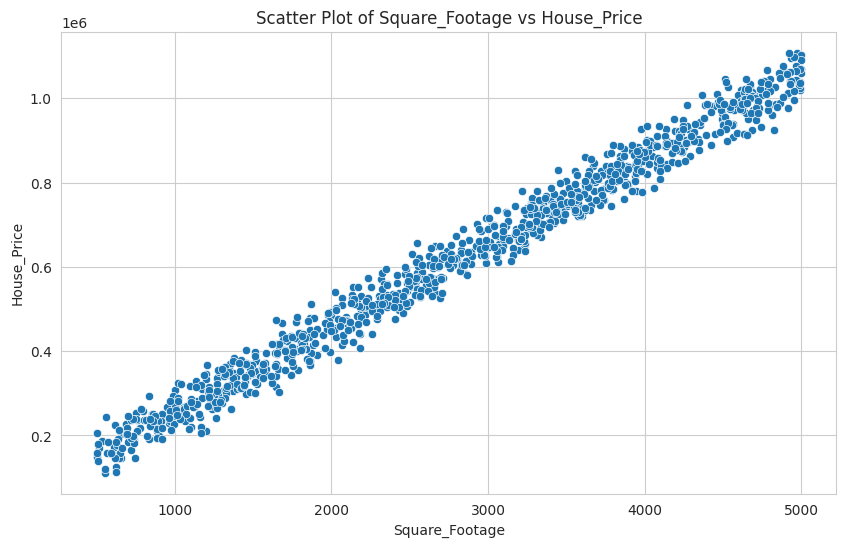

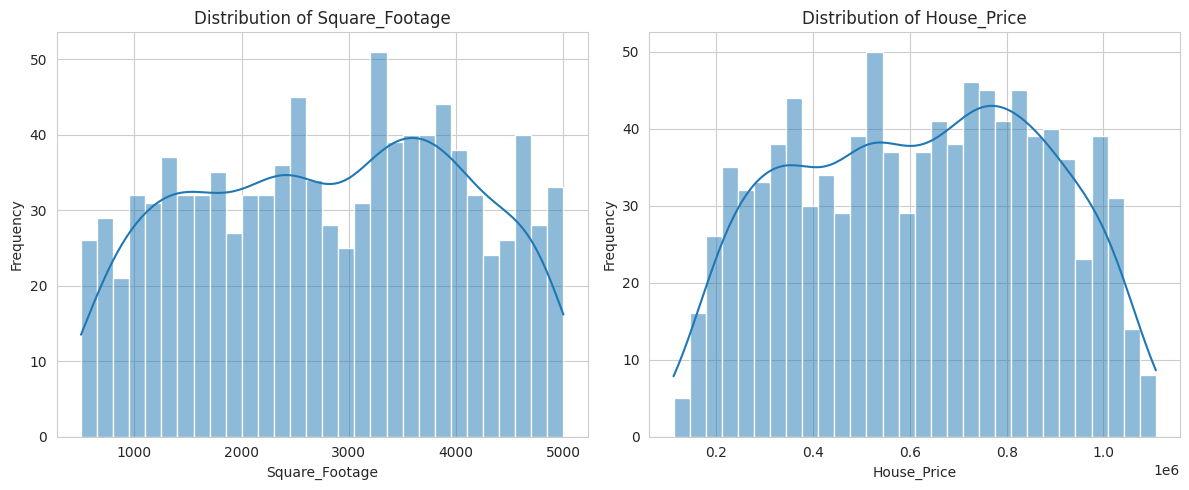

/tmp/ipykernel_1238/1345521175.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_price_by_bedrooms[feature_cat], y=mean_price_by_bedrooms[feature2], palette='viridis')


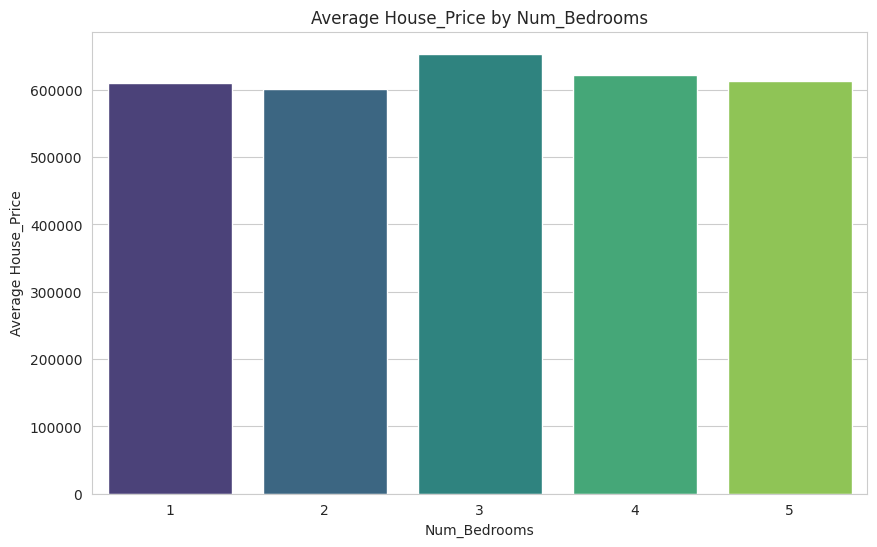

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots
sns.set_style("whitegrid")

# Choose two features for visualization
feature1 = 'Square_Footage'
feature2 = 'House_Price'
feature_cat = 'Num_Bedrooms'

# 1. Scatter Plot (representing relationship between two numerical features)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df[feature1], y=df[feature2])
plt.title(f'Scatter Plot of {feature1} vs {feature2}')
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.show()

# 2. Histograms for individual features
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(df[feature1], kde=True, bins=30)
plt.title(f'Distribution of {feature1}')
plt.xlabel(feature1)
plt.ylabel('Frequency')

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.histplot(df[feature2], kde=True, bins=30)
plt.title(f'Distribution of {feature2}')
plt.xlabel(feature2)
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# 3. Bar Plot (representing relationship between a categorical-like and numerical feature)
# Group by 'Num_Bedrooms' and calculate the mean 'House_Price'
mean_price_by_bedrooms = df.groupby(feature_cat)[feature2].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=mean_price_by_bedrooms[feature_cat], y=mean_price_by_bedrooms[feature2], palette='viridis')
plt.title(f'Average {feature2} by {feature_cat}')
plt.xlabel(feature_cat)
plt.ylabel(f'Average {feature2}')
plt.show()

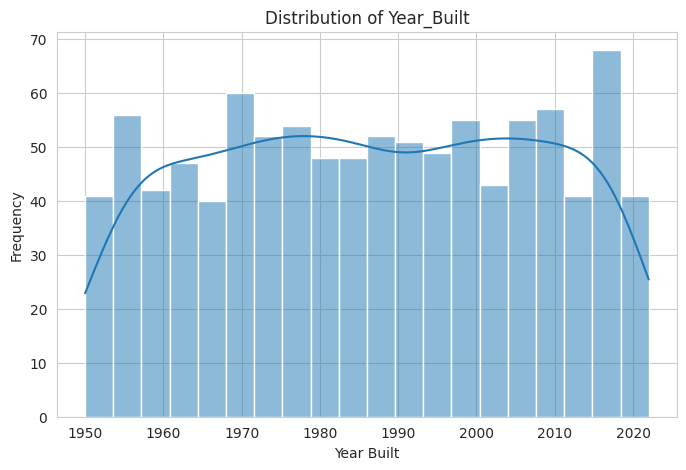

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Year_Built'], kde=True, bins=20)
plt.title('Distribution of Year_Built')
plt.xlabel('Year Built')
plt.ylabel('Frequency')
plt.show()

In [6]:
df_ads = pd.read_csv('/content/Advertising.csv')
display(df_ads.head())

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


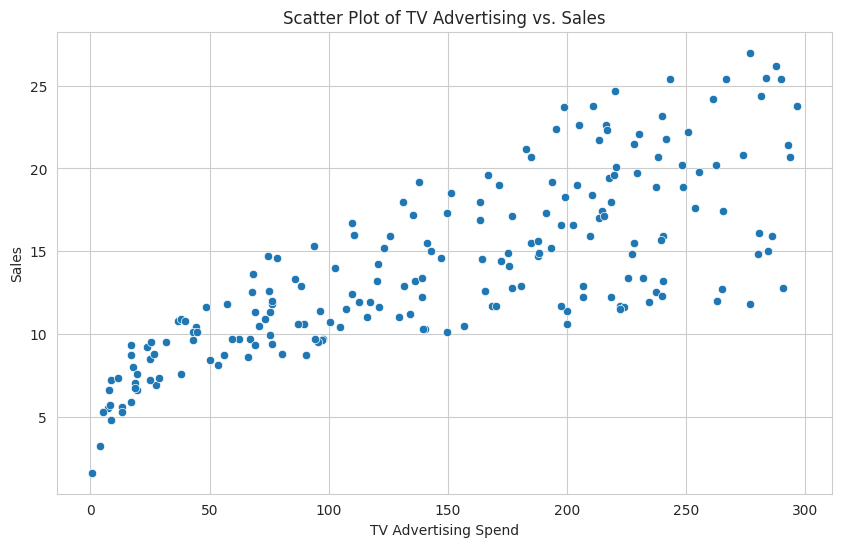

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Scatter plot for TV vs Sales
plt.figure(figsize=(10, 6))
sns.scatterplot(x='TV', y='Sales', data=df_ads)
plt.title('Scatter Plot of TV Advertising vs. Sales')
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.show()

### Bar Plot: Average Sales by TV Advertising Spend Level

To create a bar plot, which typically visualizes categorical data, I will first categorize the continuous 'TV' advertising spend into 'Low', 'Medium', and 'High' bins. Then, I will calculate the average 'Sales' for each of these categories.

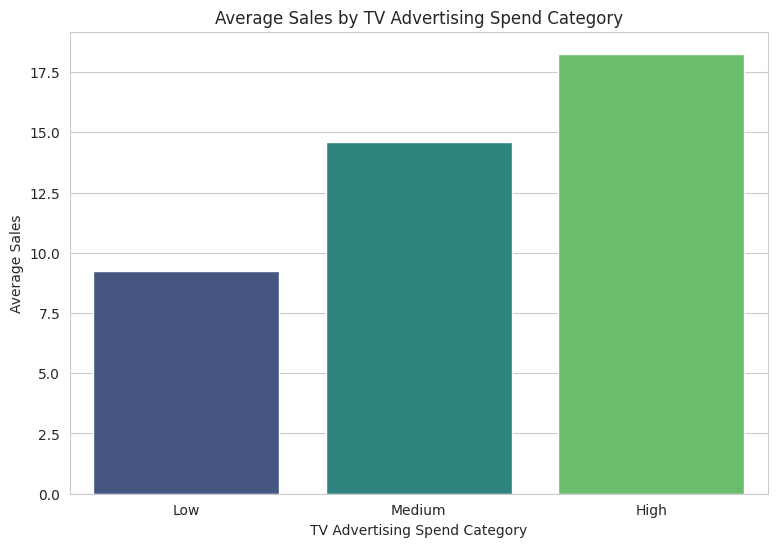

In [8]:
# Discretize 'TV' spend into categories for the bar plot
df_ads['TV_Spend_Category'] = pd.cut(
    df_ads['TV'],
    bins=3, # Create 3 bins (Low, Medium, High)
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

# Calculate the average sales for each TV spend category
average_sales_by_tv_category = df_ads.groupby('TV_Spend_Category', observed=False)['Sales'].mean().reset_index()

# Create the bar plot
plt.figure(figsize=(9, 6))
sns.barplot(x='TV_Spend_Category', y='Sales', data=average_sales_by_tv_category, palette='viridis', hue='TV_Spend_Category', legend=False)
plt.title('Average Sales by TV Advertising Spend Category')
plt.xlabel('TV Advertising Spend Category')
plt.ylabel('Average Sales')
plt.show()

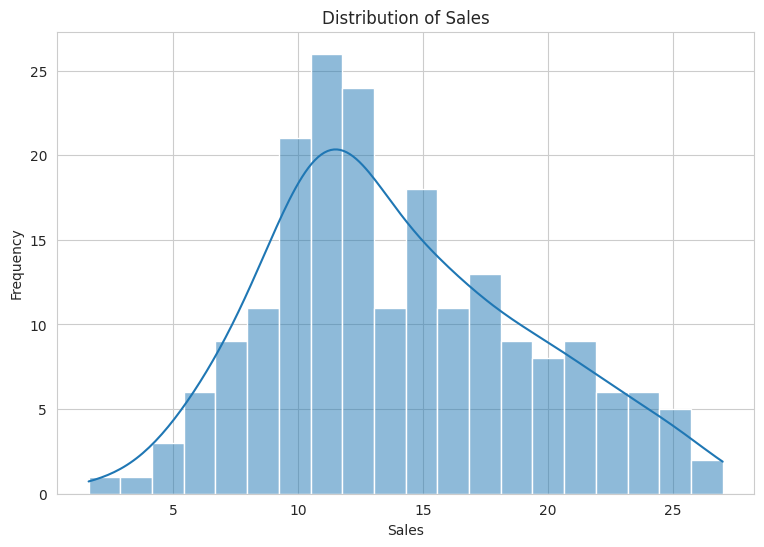

In [9]:
# Histogram for the 'Sales' distribution
plt.figure(figsize=(9, 6))
sns.histplot(df_ads['Sales'], kde=True, bins=20)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()
